<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>

# **Enterprise AI Data Lifecycle Mapping**

Estimated time needed: **40** minutes

## Overview

Enterprise AI systems succeed or fail based on lifecycle discipline, not only model quality. In this lab, you will translate a practical healthcare risk-triage use case into a full lifecycle map that spans business framing, data onboarding, validation, model training, deployment, and monitoring.

From a Data Engineering perspective, this work reflects real production responsibilities: defining data contracts, enforcing quality gates, coordinating model evidence, and building ownership clarity across technical and governance teams. You will build a lifecycle map artifact, a control matrix, policy gates tied to model evidence, and an ownership view that can be used in architecture and risk reviews.

## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Overview">Overview</a></li>
        <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
        <li><a href="#Dataset-Requirements-and-Licensing">Dataset Requirements and Licensing</a></li>
        <li><a href="#Objectives">Objectives</a></li>
        <li><a href="#Setup,-Installations,-and-Data-Quality-Checks">Setup, Installations, and Data Quality Checks</a></li>
        <li><a href="#Lifecycle-Stage-Mapping">Lifecycle Stage Mapping</a></li>
        <li><a href="#Governance-Checks-with-Model-Evidence">Governance Checks with Model Evidence</a></li>
        <li><a href="#Ownership-Matrix">Ownership Matrix</a></li>
        <li><a href="#Student-Tasks">Student Tasks</a></li>
        <li><a href="#Conclusion">Conclusion</a></li>
        <li><a href="#Author">Author</a></li>
    </ol>
</div>


## Materials and Methods

This lab combines lifecycle design with lightweight model evidence so that governance decisions are grounded in measurable outcomes. We use a reproducible **[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)** with **[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)** and **[LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)**, then evaluate with **[confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)** and threshold-based policy gates.

**Architectural Trade-offs**:
- Speed vs. accuracy: a simple linear model is fast to retrain and explain, but may underfit complex nonlinear patterns.
- Latency vs. memory constraints: richer feature pipelines and ensembles can improve signal capture while increasing runtime and infrastructure footprint.
- Governance depth vs. delivery speed: more lifecycle controls improve compliance and auditability, but add coordination overhead across teams.


## Dataset Requirements and Licensing

To keep execution deterministic and fast, we use the built-in **[Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)** from `sklearn.datasets`. In this lab context, we treat it as a proxy for a clinical risk-triage use case where lifecycle governance and operational ownership are critical.

Dataset source: `sklearn.datasets.load_breast_cancer`.

This dataset is provided under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:

- Map lifecycle stages for an enterprise AI use case.
- Assign controls, governance checks, and ownership across the lifecycle.
- Connect model evidence to deployment policy gates.
- Explain where remediation actions should occur when controls fail.


## Setup, Installations, and Data Quality Checks

We start with reproducibility and environment consistency. In enterprise CI/CD flows, a predictable runtime is a prerequisite for reliable validation, governance evidence, and incident triage. The first code cell installs all required packages quietly so learners can run the lab with minimal output noise.


In [1]:
# Install all required libraries quietly for a reproducible runtime.
%pip install -q pandas numpy scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


The installation step standardizes package availability for all learners and reduces environment drift. Next, we import all libraries in one place so dependencies are explicit and easy to audit.

The core libraries are **[pandas](https://pandas.pydata.org/docs/)** and **[NumPy](https://numpy.org/doc/)** for tabular and numerical processing, plus selected **[scikit-learn](https://scikit-learn.org/stable/documentation.html)** components for model and metric artifacts.


In [2]:
# Data handling and numerical utilities for lifecycle artifacts.
import pandas as pd
import numpy as np

# Model and evaluation components used in the governance example.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
)

# Visualization helper for control and ownership diagnostics.
import seaborn as sns
import matplotlib.pyplot as plt

With imports complete, we can now load and profile the dataset. In production settings, this is where engineers verify source integrity, schema expectations, and class distribution assumptions before any model artifact is produced.

We also capture lightweight dataset provenance metadata to reinforce traceability and reproducibility requirements.


In [3]:
# Load a built-in supervised dataset with deterministic structure.
bc = load_breast_cancer(as_frame=True)

# Copy features and append human-readable target labels.
df = bc.frame.copy()
df["target_label"] = df["target"].map({0: "malignant", 1: "benign"})

# Capture provenance details for lifecycle traceability.
dataset_meta = {
    "source": "sklearn.datasets.load_breast_cancer",
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
}

print("Dataset metadata:", dataset_meta)
display(df.head(3))

Dataset metadata: {'source': 'sklearn.datasets.load_breast_cancer', 'rows': 569, 'columns': 32}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_label
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant


The preview confirms that we have a stable tabular structure and labeled outcome classes. Before modeling or control assignment, we run a compact data quality gate aligned with enterprise governance practices.

This gate checks null completeness, duplicate risk, schema visibility, and class balance so lifecycle design decisions are based on trustworthy inputs.


In [4]:
# Profile missing values to detect ingestion or transformation failures.
null_counts = df.isnull().sum().sort_values(ascending=False)

# Snapshot inferred schema to support contract and lineage checks.
schema_snapshot = df.dtypes.astype(str).rename("dtype")

# Detect duplicate rows and inspect class distribution risk.
duplicate_rows = int(df.duplicated().sum())
class_balance = df["target_label"].value_counts(normalize=True).rename("ratio")

print("Top null counts:")
print(null_counts.head(8))
print("\nDuplicate rows:", duplicate_rows)
print("\nClass balance:")
print(class_balance.round(3))
display(schema_snapshot.head(10))

Top null counts:
mean radius            0
mean texture           0
mean perimeter         0
mean area              0
mean smoothness        0
mean compactness       0
mean concavity         0
mean concave points    0
dtype: int64

Duplicate rows: 0

Class balance:
target_label
benign       0.627
malignant    0.373
Name: ratio, dtype: float64


mean radius               float64
mean texture              float64
mean perimeter            float64
mean area                 float64
mean smoothness           float64
mean compactness          float64
mean concavity            float64
mean concave points       float64
mean symmetry             float64
mean fractal dimension    float64
Name: dtype, dtype: str

The output from these checks becomes lifecycle evidence. For example, high null rates would route remediation to Data Acquisition or Data Validation stages, while skewed class balance may trigger fairness or sampling controls during Feature Engineering and Model Validation.

## Lifecycle Stage Mapping

Next, we define a stage taxonomy and a compact control catalog. This gives us a structured language for mapping who owns each stage and what governance checks must be enforced.


In [5]:
# Define lifecycle stages aligned with enterprise AI operations.
stages = [
    "Business Framing",
    "Data Acquisition",
    "Data Validation",
    "Feature Engineering",
    "Model Training",
    "Model Validation",
    "Deployment",
    "Monitoring and Drift Response",
]

# Define a reusable catalog of controls for audit and policy checks.
control_catalog = pd.DataFrame(
    [
        {"control_id": "C1", "control_name": "PII scan", "type": "governance"},
        {"control_id": "C2", "control_name": "Schema contract test", "type": "quality"},
        {
            "control_id": "C3",
            "control_name": "Bias and parity check",
            "type": "responsible_ai",
        },
        {
            "control_id": "C4",
            "control_name": "Model performance gate",
            "type": "quality",
        },
        {
            "control_id": "C5",
            "control_name": "Drift threshold alert",
            "type": "operations",
        },
    ]
)

display(pd.DataFrame({"lifecycle_stage": stages}))
display(control_catalog)

,lifecycle_stage
0,Business Framing
1,Data Acquisition
2,Data Validation
3,Feature Engineering
4,Model Training
5,Model Validation
6,Deployment
7,Monitoring and Drift Response


,control_id,control_name,type
0,C1,PII scan,governance
1,C2,Schema contract test,quality
2,C3,Bias and parity check,responsible_ai
3,C4,Model performance gate,quality
4,C5,Drift threshold alert,operations


The taxonomy and control catalog provide reusable building blocks, but governance decisions require explicit mapping. In the next step, we assign each lifecycle stage to a primary owner and attach required controls.

This mapping artifact is the core deliverable that architecture, compliance, and ML platform teams can review together.


In [6]:
# Map each stage to one owner and one or more required controls.
lifecycle_map = [
    {"stage": "Business Framing", "owner": "Product Owner", "controls": "C1"},
    {"stage": "Data Acquisition", "owner": "Data Engineer", "controls": "C1,C2"},
    {"stage": "Data Validation", "owner": "Data Engineer", "controls": "C2"},
    {"stage": "Feature Engineering", "owner": "ML Engineer", "controls": "C2,C3"},
    {"stage": "Model Training", "owner": "ML Engineer", "controls": "C3,C4"},
    {"stage": "Model Validation", "owner": "Risk Officer", "controls": "C3,C4"},
    {"stage": "Deployment", "owner": "ML Engineer", "controls": "C4"},
    {
        "stage": "Monitoring and Drift Response",
        "owner": "Data Steward",
        "controls": "C5",
    },
]

# Convert the map to a DataFrame and derive simple control counts.
lifecycle_map_df = pd.DataFrame(lifecycle_map)
lifecycle_map_df["control_count"] = (
    lifecycle_map_df["controls"].str.split(",").str.len()
)

display(lifecycle_map_df)

,stage,owner,controls,control_count
0,Business Framing,Product Owner,C1,1
1,Data Acquisition,Data Engineer,"C1,C2",2
2,Data Validation,Data Engineer,C2,1
3,Feature Engineering,ML Engineer,"C2,C3",2
4,Model Training,ML Engineer,"C3,C4",2
5,Model Validation,Risk Officer,"C3,C4",2
6,Deployment,ML Engineer,C4,1
7,Monitoring and Drift Response,Data Steward,C5,1


At this point, we have a stage-control-owner blueprint. To make governance operational rather than theoretical, we now connect lifecycle controls to measurable model outcomes.

## Governance Checks with Model Evidence

We will train a compact baseline using **[train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)** and a **[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)** so policy checks can reference concrete performance signals.


In [7]:
# Select predictors and binary target for a controlled governance example.
X = df.drop(columns=["target", "target_label"])
y = df["target"]

# Split data with a fixed seed for reproducible evidence generation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Build and fit a simple, traceable model pipeline.
clf = Pipeline(
    [("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]
)

clf.fit(X_train, y_train)
print("Training complete. Train rows:", X_train.shape[0], "Test rows:", X_test.shape[0])

Training complete. Train rows: 426 Test rows: 143


The training step gives us an auditable model artifact and a fixed evaluation split. Next, we compute core metrics that frequently appear in model-risk reviews and release decisions.

Notice how this bridges two lifecycle stages: Model Validation (metric generation) and Deployment (policy approval).


In [8]:
# Generate predictions and calibrated probabilities for KPI reporting.
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Compute validation metrics used in governance committees.
metric_report = pd.DataFrame(
    [
        {"metric": "accuracy", "value": accuracy_score(y_test, y_pred)},
        {"metric": "precision", "value": precision_score(y_test, y_pred)},
        {"metric": "recall", "value": recall_score(y_test, y_pred)},
        {"metric": "roc_auc", "value": roc_auc_score(y_test, y_prob)},
    ]
)

# Build confusion matrix for error-surface interpretation.
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"])

display(metric_report.round(4))
display(cm_df)

,metric,value
0,accuracy,0.9860
1,precision,0.9889
2,recall,0.9889
3,roc_auc,0.9977


,pred_0,pred_1
actual_0,52,1
actual_1,1,89


These metrics become control evidence for `C4` (model performance gate). Instead of subjective approval, release readiness can be decided using explicit thresholds linked to organizational risk appetite.

In the next micro-step, we encode this logic as policy gates and classify each metric as `pass` or `review`.


In [9]:
# Define threshold policies required for deployment approval.
policy_thresholds = {"accuracy": 0.90, "recall": 0.90, "roc_auc": 0.95}

# Convert observed metrics into a lookup dictionary.
observed = dict(zip(metric_report["metric"], metric_report["value"]))

# Evaluate each metric against policy and mark required action.
gate_results = []
for metric_name, threshold in policy_thresholds.items():
    observed_value = float(observed.get(metric_name, np.nan))
    gate_results.append(
        {
            "metric": metric_name,
            "threshold": threshold,
            "observed": round(observed_value, 4),
            "status": "pass" if observed_value >= threshold else "review",
        }
    )

gates_df = pd.DataFrame(gate_results)
display(gates_df)

,metric,threshold,observed,status
0,accuracy,0.90,0.9860,pass
1,recall,0.90,0.9889,pass
2,roc_auc,0.95,0.9977,pass


A `review` status signals that release should not proceed without remediation. Typical owners are:

- Data Engineer for upstream quality defects.
- ML Engineer for feature/model adjustments.
- Risk Officer for threshold or policy exceptions.

## Ownership Matrix

To make responsibilities explicit, we now create a compact matrix that shows who is accountable or responsible at each lifecycle stage.


In [10]:
# Assign lifecycle ownership using compact RACI-style labels.
raci_rows = [
    ("Business Framing", "Product Owner", "A"),
    ("Data Acquisition", "Data Engineer", "A"),
    ("Data Validation", "Data Engineer", "R"),
    ("Feature Engineering", "ML Engineer", "R"),
    ("Model Training", "ML Engineer", "A"),
    ("Model Validation", "Risk Officer", "A"),
    ("Deployment", "ML Engineer", "R"),
    ("Monitoring and Drift Response", "Data Steward", "A"),
]

# Build a matrix suitable for governance review meetings.
raci_df = pd.DataFrame(raci_rows, columns=["stage", "role", "assignment"])
ownership_matrix = raci_df.pivot_table(
    index="stage", columns="role", values="assignment", aggfunc="first"
).fillna("-")

display(ownership_matrix)

role,Data Engineer,Data Steward,ML Engineer,Product Owner,Risk Officer
stage,,,,,
Business Framing,-,-,-,A,-
Data Acquisition,A,-,-,-,-
Data Validation,R,-,-,-,-
Deployment,-,-,R,-,-
Feature Engineering,-,-,R,-,-
Model Training,-,-,A,-,-
Model Validation,-,-,-,-,A
Monitoring and Drift Response,-,A,-,-,-


The ownership matrix clarifies accountability, but reviewers often need a quick visual signal of control concentration. The next cell creates a heatmap showing how control IDs are distributed by owner.

This makes it easier to spot overloaded teams or weak separation of duties.


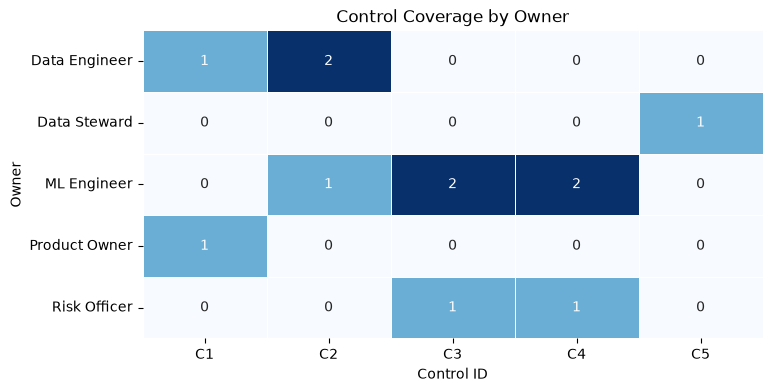

In [11]:
# Expand control lists to one row per stage-control-owner tuple.
expanded = lifecycle_map_df.assign(
    control=lifecycle_map_df["controls"].str.split(",")
).explode("control")

# Aggregate control ownership counts for visualization.
coverage = expanded.groupby(["owner", "control"]).size().reset_index(name="count")
heatmap_df = coverage.pivot(index="owner", columns="control", values="count").fillna(0)

# Plot a compact heatmap for governance discussion.
plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_df, annot=True, cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Control Coverage by Owner")
plt.xlabel("Control ID")
plt.ylabel("Owner")
plt.show()

The heatmap helps identify concentration risk. If one role owns most controls, your organization may need backup ownership or stronger automated checks to reduce operational fragility.

## Student Tasks

Use these exercises to practice lifecycle mapping decisions under different enterprise assumptions.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Create a new enterprise use case (for example, fraud detection or claims triage), map at least six lifecycle stages, and assign one owner plus one control to each stage.</b>
</div>


In [ ]:
# TODO: Define a list of six or more lifecycle stages for your chosen use case.
# TODO: Create a DataFrame with columns: stage, owner, controls.
# TODO: Display the lifecycle map and inspect the control distribution.

# Example lifecycle map for a fraud-detection use case.
fraud_map = pd.DataFrame(
    [
        {
            "stage": "Business Framing",
            "owner": "Product Owner",
            "controls": "Policy scope review",
        },
        {
            "stage": "Data Acquisition",
            "owner": "Data Engineer",
            "controls": "Source access audit",
        },
        {
            "stage": "Data Validation",
            "owner": "Data Engineer",
            "controls": "Schema contract test",
        },
        {
            "stage": "Feature Engineering",
            "owner": "ML Engineer",
            "controls": "Feature lineage check",
        },
        {
            "stage": "Model Training",
            "owner": "ML Engineer",
            "controls": "Experiment tracking",
        },
        {
            "stage": "Model Validation",
            "owner": "Risk Officer",
            "controls": "Fairness threshold check",
        },
        {
            "stage": "Deployment",
            "owner": "ML Engineer",
            "controls": "Release checklist sign-off",
        },
        {
            "stage": "Monitoring",
            "owner": "Data Steward",
            "controls": "Drift alert policy",
        },
    ]
)

# Review the created mapping artifact.
display(fraud_map)

,stage,owner,controls
0,Business Framing,Product Owner,Policy scope review
1,Data Acquisition,Data Engineer,Source access audit
2,Data Validation,Data Engineer,Schema contract test
3,Feature Engineering,ML Engineer,Feature lineage check
4,Model Training,ML Engineer,Experiment tracking
5,Model Validation,Risk Officer,Fairness threshold check
6,Deployment,ML Engineer,Release checklist sign-off
7,Monitoring,Data Steward,Drift alert policy


<details><summary>Click here for the solution</summary>

```python
# Example lifecycle map for a fraud-detection use case.
fraud_map = pd.DataFrame([
    {'stage': 'Business Framing', 'owner': 'Product Owner', 'controls': 'Policy scope review'},
    {'stage': 'Data Acquisition', 'owner': 'Data Engineer', 'controls': 'Source access audit'},
    {'stage': 'Data Validation', 'owner': 'Data Engineer', 'controls': 'Schema contract test'},
    {'stage': 'Feature Engineering', 'owner': 'ML Engineer', 'controls': 'Feature lineage check'},
    {'stage': 'Model Training', 'owner': 'ML Engineer', 'controls': 'Experiment tracking'},
    {'stage': 'Model Validation', 'owner': 'Risk Officer', 'controls': 'Fairness threshold check'},
    {'stage': 'Deployment', 'owner': 'ML Engineer', 'controls': 'Release checklist sign-off'},
    {'stage': 'Monitoring', 'owner': 'Data Steward', 'controls': 'Drift alert policy'}
])

# Review the created mapping artifact.
display(fraud_map)
```

</details>

Strong submissions usually show clear owner boundaries and controls that are testable, not only descriptive.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #2: </h1>
<b>Set stricter governance gates (for example, recall >= 0.94 and roc_auc >= 0.97), rerun the gate logic, and explain which lifecycle stage should take action if a metric fails.</b>
</div>


In [ ]:
# TODO: Update policy_thresholds with stricter values for recall and roc_auc.
# TODO: Recompute gate_results and display a new DataFrame.
# TODO: Write one sentence naming the lifecycle stage that owns remediation.

# Tighten policy thresholds to simulate stricter governance.
strict_thresholds = {"accuracy": 0.92, "recall": 0.94, "roc_auc": 0.97}

# Re-evaluate each metric under stricter expectations.
strict_results = []
for metric_name, threshold in strict_thresholds.items():
    observed_value = float(observed.get(metric_name, np.nan))
    strict_results.append(
        {
            "metric": metric_name,
            "threshold": threshold,
            "observed": round(observed_value, 4),
            "status": "pass" if observed_value >= threshold else "review",
        }
    )

strict_gates_df = pd.DataFrame(strict_results)
display(strict_gates_df)

# If a metric fails, remediation is typically owned by Model Validation and ML Engineering stages.

,metric,threshold,observed,status
0,accuracy,0.92,0.9860,pass
1,recall,0.94,0.9889,pass
2,roc_auc,0.97,0.9977,pass


<details><summary>Click here for the solution</summary>

```python
# Tighten policy thresholds to simulate stricter governance.
strict_thresholds = {'accuracy': 0.92, 'recall': 0.94, 'roc_auc': 0.97}

# Re-evaluate each metric under stricter expectations.
strict_results = []
for metric_name, threshold in strict_thresholds.items():
    observed_value = float(observed.get(metric_name, np.nan))
    strict_results.append({
        'metric': metric_name,
        'threshold': threshold,
        'observed': round(observed_value, 4),
        'status': 'pass' if observed_value >= threshold else 'review'
    })

strict_gates_df = pd.DataFrame(strict_results)
display(strict_gates_df)

# If a metric fails, remediation is typically owned by Model Validation and ML Engineering stages.
```

</details>

## Conclusion

You created a practical enterprise lifecycle mapping artifact that links stages, controls, evidence, and ownership. This is the foundation of AI production readiness: measurable gates, explicit accountability, and clear remediation paths when quality or governance checks fail.

## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-23 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
